<a href="https://colab.research.google.com/github/buthaina156/Car_Price_Prediction/blob/main/Car_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression as LR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor as DTR

In [2]:
!git clone https://github.com/alexeygrigorev/mlbookcamp-code

Cloning into 'mlbookcamp-code'...
remote: Enumerating objects: 4489, done.
remote: Counting objects: 100% (55/55), done.
remote: Compressing objects: 100% (22/22), done.
remote: Total 4489 (delta 45), reused 33 (delta 33), pack-reused 4434 (from 1)
Receiving objects: 100% (4489/4489), 9.03 MiB | 20.33 MiB/s, done.
Resolving deltas: 100% (2720/2720), done.


In [3]:
dataset = pd.read_csv('/content/mlbookcamp-code/chapter-02-car-price/data.csv')

In [4]:
dataset.head(3)

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350


In [5]:
len(dataset.columns)

16

In [6]:
dataset.shape

(11914, 16)

In [7]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Make               11914 non-null  object 
 1   Model              11914 non-null  object 
 2   Year               11914 non-null  int64  
 3   Engine Fuel Type   11911 non-null  object 
 4   Engine HP          11845 non-null  float64
 5   Engine Cylinders   11884 non-null  float64
 6   Transmission Type  11914 non-null  object 
 7   Driven_Wheels      11914 non-null  object 
 8   Number of Doors    11908 non-null  float64
 9   Market Category    8172 non-null   object 
 10  Vehicle Size       11914 non-null  object 
 11  Vehicle Style      11914 non-null  object 
 12  highway MPG        11914 non-null  int64  
 13  city mpg           11914 non-null  int64  
 14  Popularity         11914 non-null  int64  
 15  MSRP               11914 non-null  int64  
dtypes: float64(3), int64(5

In [8]:
print(dataset.isnull().sum())

Make                    0
Model                   0
Year                    0
Engine Fuel Type        3
Engine HP              69
Engine Cylinders       30
Transmission Type       0
Driven_Wheels           0
Number of Doors         6
Market Category      3742
Vehicle Size            0
Vehicle Style           0
highway MPG             0
city mpg                0
Popularity              0
MSRP                    0
dtype: int64


Cleaning

In [9]:
dataset.columns = dataset.columns.str.capitalize()

In [10]:
dataset.head(2)

,Make,Model,Year,Engine fuel type,Engine hp,Engine cylinders,Transmission type,Driven_wheels,Number of doors,Market category,Vehicle size,Vehicle style,Highway mpg,City mpg,Popularity,Msrp
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650


In [11]:
dataset.columns = dataset.columns.str.replace('_',' ')

In [12]:
dataset.head(3)

,Make,Model,Year,Engine fuel type,Engine hp,Engine cylinders,Transmission type,Driven wheels,Number of doors,Market category,Vehicle size,Vehicle style,Highway mpg,City mpg,Popularity,Msrp
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350


In [13]:
dataset.rename(columns={'Msrp':'Price'},inplace=True)

In [14]:
dataset.columns

Index(['Make', 'Model', 'Year', 'Engine fuel type', 'Engine hp',
       'Engine cylinders', 'Transmission type', 'Driven wheels',
       'Number of doors', 'Market category', 'Vehicle size', 'Vehicle style',
       'Highway mpg', 'City mpg', 'Popularity', 'Price'],
      dtype='object')

EDA

In [15]:
pd.options.display.float_format = '{:,.2f}'.format
dataset.describe()

,Year,Engine hp,Engine cylinders,Number of doors,Highway mpg,City mpg,Popularity,Price
count,"11,914.00","11,845.00","11,884.00","11,908.00","11,914.00","11,914.00","11,914.00","11,914.00"
mean,"2,010.38",249.39,5.63,3.44,26.64,19.73,"1,554.91","40,594.74"
std,7.58,109.19,1.78,0.88,8.86,8.99,"1,441.86","60,109.10"
min,"1,990.00",55.00,0.00,2.00,12.00,7.00,2.00,"2,000.00"
25%,"2,007.00",170.00,4.00,2.00,22.00,16.00,549.00,"21,000.00"
50%,"2,015.00",227.00,6.00,4.00,26.00,18.00,"1,385.00","29,995.00"
75%,"2,016.00",300.00,6.00,4.00,30.00,22.00,"2,009.00","42,231.25"
max,"2,017.00","1,001.00",16.00,4.00,354.00,137.00,"5,657.00","2,065,902.00"


In [16]:
dataset.describe(include=['O'])

,Make,Model,Engine fuel type,Transmission type,Driven wheels,Market category,Vehicle size,Vehicle style
count,11914,11914,11911,11914,11914,8172,11914,11914
unique,48,915,10,5,4,71,3,16
top,Chevrolet,Silverado 1500,regular unleaded,AUTOMATIC,front wheel drive,Crossover,Compact,Sedan
freq,1123,156,7172,8266,4787,1110,4764,3048


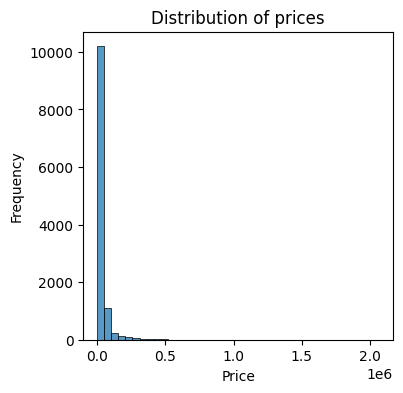

In [17]:
plt.figure(figsize=(4, 4))
sns.histplot(dataset.Price, bins=40)
plt.ylabel('Frequency')
plt.xlabel('Price')
plt.title('Distribution of prices')
plt.show()

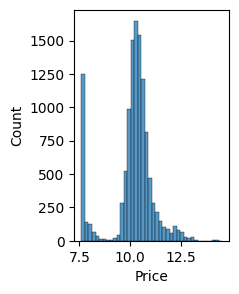

In [18]:
dataset['Price'] = np.log1p(dataset.Price)
plt.figure(figsize=(2, 3))
sns.histplot(dataset.Price, bins=40)
plt.show()

In [19]:
pd.options.display.float_format = '{:,.2f}'.format
dataset.describe()

,Year,Engine hp,Engine cylinders,Number of doors,Highway mpg,City mpg,Popularity,Price
count,"11,914.00","11,845.00","11,884.00","11,908.00","11,914.00","11,914.00","11,914.00","11,914.00"
mean,"2,010.38",249.39,5.63,3.44,26.64,19.73,"1,554.91",10.11
std,7.58,109.19,1.78,0.88,8.86,8.99,"1,441.86",1.11
min,"1,990.00",55.00,0.00,2.00,12.00,7.00,2.00,7.60
25%,"2,007.00",170.00,4.00,2.00,22.00,16.00,549.00,9.95
50%,"2,015.00",227.00,6.00,4.00,26.00,18.00,"1,385.00",10.31
75%,"2,016.00",300.00,6.00,4.00,30.00,22.00,"2,009.00",10.65
max,"2,017.00","1,001.00",16.00,4.00,354.00,137.00,"5,657.00",14.54


preprocessing

In [20]:
duplicate_rows_data = dataset[dataset.duplicated()]
print("number of duplicate rows: ", duplicate_rows_data.shape)

number of duplicate rows:  (715, 16)


In [21]:
dataset = dataset.drop_duplicates()

In [22]:
duplicate_rows_data = dataset[dataset.duplicated()]
print("number of duplicate rows: ", duplicate_rows_data.shape)

number of duplicate rows:  (0, 16)


In [23]:
for col in dataset.columns:
    print( col,':', dataset[col].nunique() )
    print(dataset[col].value_counts().nlargest(5))
    print('\n' + '*' * 20 + '\n')

Make : 48
Make
Chevrolet     1083
Ford           825
Toyota         719
Volkswagen     568
Nissan         551
Name: count, dtype: int64

********************

Model : 915
Model
Silverado 1500    156
Tundra            129
F-150             126
Sierra 1500        90
Frontier           76
Name: count, dtype: int64

********************

Year : 28
Year
2016    2073
2015    2065
2017    1625
2014     554
2009     364
Name: count, dtype: int64

********************

Engine fuel type : 10
Engine fuel type
regular unleaded                  6658
premium unleaded (required)       1956
premium unleaded (recommended)    1392
flex-fuel (unleaded/E85)           887
diesel                             150
Name: count, dtype: int64

********************

Engine hp : 356
Engine hp
200.00    378
170.00    261
240.00    251
285.00    246
210.00    243
Name: count, dtype: int64

********************

Engine cylinders : 9
Engine cylinders
4.00     4362
6.00     4291
8.00     1965
12.00     228
5.00      169

In [24]:
dataset.head()

,Make,Model,Year,Engine fuel type,Engine hp,Engine cylinders,Transmission type,Driven wheels,Number of doors,Market category,Vehicle size,Vehicle style,Highway mpg,City mpg,Popularity,Price
0,BMW,1 Series M,2011,premium unleaded (required),335.00,6.00,MANUAL,rear wheel drive,2.00,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,10.74
1,BMW,1 Series,2011,premium unleaded (required),300.00,6.00,MANUAL,rear wheel drive,2.00,"Luxury,Performance",Compact,Convertible,28,19,3916,10.61
2,BMW,1 Series,2011,premium unleaded (required),300.00,6.00,MANUAL,rear wheel drive,2.00,"Luxury,High-Performance",Compact,Coupe,28,20,3916,10.50
3,BMW,1 Series,2011,premium unleaded (required),230.00,6.00,MANUAL,rear wheel drive,2.00,"Luxury,Performance",Compact,Coupe,28,18,3916,10.29
4,BMW,1 Series,2011,premium unleaded (required),230.00,6.00,MANUAL,rear wheel drive,2.00,Luxury,Compact,Convertible,28,18,3916,10.45


Fill Missing values

In [25]:
print(dataset.isnull().sum())

Make                    0
Model                   0
Year                    0
Engine fuel type        3
Engine hp              69
Engine cylinders       30
Transmission type       0
Driven wheels           0
Number of doors         6
Market category      3376
Vehicle size            0
Vehicle style           0
Highway mpg             0
City mpg                0
Popularity              0
Price                   0
dtype: int64


In [26]:
print(dataset['Engine fuel type'].mode())

0    regular unleaded
Name: Engine fuel type, dtype: object


In [27]:
dataset['Engine fuel type']=dataset['Engine fuel type'].fillna(dataset['Engine fuel type'].mode()[0])

In [28]:
print(dataset['Number of doors'].mode())

0   4.00
Name: Number of doors, dtype: float64


In [29]:
dataset['Engine hp']=dataset['Engine hp'].fillna(dataset['Engine hp'].mean())
dataset['Engine cylinders']=dataset['Engine cylinders'].fillna(dataset['Engine cylinders'].mean())
dataset['Number of doors']=dataset['Number of doors'].fillna(dataset['Number of doors'].mode()[0])

In [30]:
dataset = dataset.drop('Market category', axis=1)

In [31]:
print(dataset.isnull().sum())

Make                 0
Model                0
Year                 0
Engine fuel type     0
Engine hp            0
Engine cylinders     0
Transmission type    0
Driven wheels        0
Number of doors      0
Vehicle size         0
Vehicle style        0
Highway mpg          0
City mpg             0
Popularity           0
Price                0
dtype: int64


Encoding

In [32]:
dataset.head(2)

,Make,Model,Year,Engine fuel type,Engine hp,Engine cylinders,Transmission type,Driven wheels,Number of doors,Vehicle size,Vehicle style,Highway mpg,City mpg,Popularity,Price
0,BMW,1 Series M,2011,premium unleaded (required),335.00,6.00,MANUAL,rear wheel drive,2.00,Compact,Coupe,26,19,3916,10.74
1,BMW,1 Series,2011,premium unleaded (required),300.00,6.00,MANUAL,rear wheel drive,2.00,Compact,Convertible,28,19,3916,10.61


In [33]:
dataset.shape

(11199, 15)

In [34]:
dataset = dataset.drop(columns=['Engine fuel type','Vehicle style','Driven wheels'] , axis=1)

In [35]:
dataset.columns

Index(['Make', 'Model', 'Year', 'Engine hp', 'Engine cylinders',
       'Transmission type', 'Number of doors', 'Vehicle size', 'Highway mpg',
       'City mpg', 'Popularity', 'Price'],
      dtype='object')

In [36]:
dataset = pd.get_dummies(dataset, columns=['Make','Model','Transmission type','Vehicle size'])

In [37]:
dataset.shape

(11199, 979)

In [38]:
dataset.head(3)

,Year,Engine hp,Engine cylinders,Number of doors,Highway mpg,City mpg,Popularity,Price,Make_Acura,Make_Alfa Romeo,...,Model_xB,Model_xD,Transmission type_AUTOMATED_MANUAL,Transmission type_AUTOMATIC,Transmission type_DIRECT_DRIVE,Transmission type_MANUAL,Transmission type_UNKNOWN,Vehicle size_Compact,Vehicle size_Large,Vehicle size_Midsize
0,2011,335.00,6.00,2.00,26,19,3916,10.74,False,False,...,False,False,False,False,False,True,False,True,False,False
1,2011,300.00,6.00,2.00,28,19,3916,10.61,False,False,...,False,False,False,False,False,True,False,True,False,False
2,2011,300.00,6.00,2.00,28,20,3916,10.50,False,False,...,False,False,False,False,False,True,False,True,False,False


Split

In [39]:
x = dataset.drop('Price', axis=1)
y = dataset['Price']

In [40]:
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size = 0.2, random_state = 42)

In [41]:
x_train.head()

,Year,Engine hp,Engine cylinders,Number of doors,Highway mpg,City mpg,Popularity,Make_Acura,Make_Alfa Romeo,Make_Aston Martin,...,Model_xB,Model_xD,Transmission type_AUTOMATED_MANUAL,Transmission type_AUTOMATIC,Transmission type_DIRECT_DRIVE,Transmission type_MANUAL,Transmission type_UNKNOWN,Vehicle size_Compact,Vehicle size_Large,Vehicle size_Midsize
61,1991,217.00,5.00,4.00,22,16,3105,False,False,False,...,False,False,False,False,False,True,False,False,False,True
6307,2016,304.00,6.00,4.00,28,18,155,False,False,False,...,False,False,False,True,False,False,False,False,True,False
4306,2013,325.00,6.00,4.00,25,17,190,False,False,False,...,False,False,False,True,False,False,False,False,False,True
495,2015,270.00,6.00,4.00,21,17,2031,False,False,False,...,False,False,False,True,False,False,False,False,False,True
6613,2011,420.00,8.00,4.00,25,16,190,False,False,False,...,False,False,False,True,False,False,False,False,True,False


In [42]:
y_train.head()

,Price
61,7.60
6307,10.43
4306,10.52
495,10.63
6613,10.98


Modeling:Linaer Regression

In [43]:
model = LR()

In [44]:
model.fit(x_train , y_train)

LinearRegression()

In [45]:
y_pred_train= model.predict(x_train)
mse_train = mean_squared_error(y_train, y_pred_train)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(y_train, y_pred_train)
print(f"RMSE (Root Mean Squared Error) on training data: {rmse_train}")
print(f"R^2 Score on training data: {r2_train}")


RMSE (Root Mean Squared Error) on training data: 0.16849129505784236
R^2 Score on training data: 0.9748185181552406


Modeling using :Decision Tree

In [46]:
Model = DTR()

In [47]:
Model.fit(x_train , y_train)

DecisionTreeRegressor()

In [48]:
pred_train = Model.predict(x_train)
mse_train = mean_squared_error(y_train, pred_train)
rmse_train_DTR = np.sqrt(mse_train)
r2_train_DTR = r2_score(y_train, pred_train)
print(f"RMSE (Root Mean Squared Error) on training data: {rmse_train_DTR}")
print(f"R^2 Score on training data: {r2_train_DTR}")


RMSE (Root Mean Squared Error) on training data: 0.06067986827150155
R^2 Score on training data: 0.99673400432595


Predict on Test

In [49]:
pred_test = Model.predict(x_test)
mse_test = mean_squared_error(y_test, pred_test)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, pred_test)
print(f"RMSE (Root Mean Squared Error) on training data: {rmse_test}")
print(f"R^2 Score on training data: {r2_test}")


RMSE (Root Mean Squared Error) on training data: 0.12908500179383559
R^2 Score on training data: 0.9852880650936201
